In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
df = pd.read_csv('/content/Fact_Energy_Consumption 2(Sheet1).csv')
display(df.head(5))

,Consumption_id,timestamp,machine_id,MSEB_Zone_id,KWH_Reading,Consumption,P.F,Parts_produced,Batch_ID,Molten_Metal
0,FC001,2024-07-30 00:00:00,SP1,MZ1,1281,50,0.71,54,Unknown,0
1,FC002,2024-07-30 01:00:00,SP1,MZ1,1331,50,0.62,57,Unknown,0
2,FC003,2024-07-30 02:00:00,SP1,MZ1,1393,62,0.64,56,Unknown,0
3,FC004,2024-07-30 03:00:00,SP1,MZ1,1455,62,0.57,54,Unknown,0
4,FC005,2024-07-30 04:00:00,SP1,MZ1,1526,71,0.56,54,Unknown,0


In [25]:
import pandas as pd

# 1. Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 2. Group by date and sum Consumption
daily_consumption = df.groupby(df['timestamp'].dt.date)['Consumption'].sum().reset_index()

# 3. Rename column
daily_consumption.rename(columns={'timestamp': 'date'}, inplace=True)

# 4. Convert date column to datetime
daily_consumption['date'] = pd.to_datetime(daily_consumption['date'])

# 5. Set index
daily_consumption.set_index('date', inplace=True)

# 6. Display first few rows
print(daily_consumption.head())

            Consumption
date                   
2024-07-30        43849
2024-07-31        43759
2024-08-01        43925
2024-08-02        43744
2024-08-03        43714


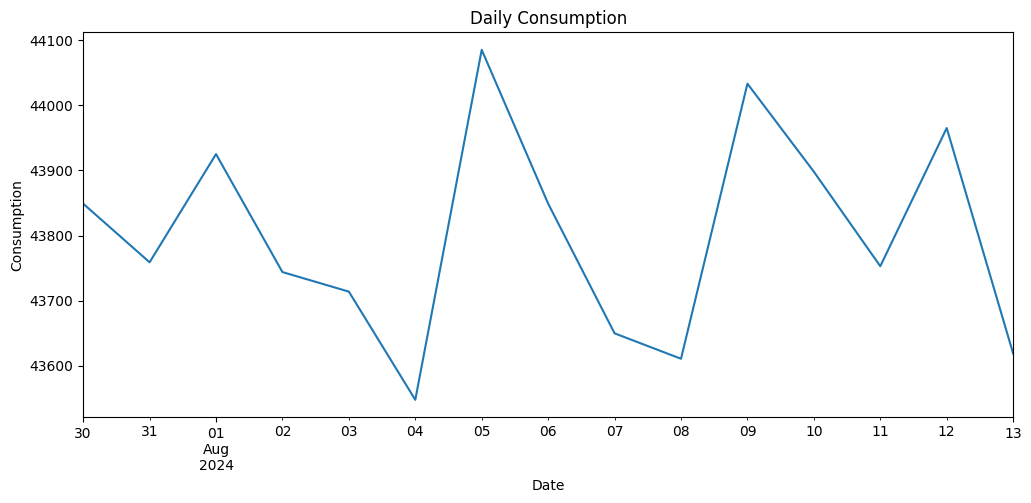

In [26]:
import matplotlib.pyplot as plt

daily_consumption['Consumption'].plot(figsize=(12,5))
plt.title("Daily Consumption")
plt.xlabel("Date")
plt.ylabel("Consumption")
plt.show()

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Consumption_id  4320 non-null   object        
 1   timestamp       4320 non-null   datetime64[ns]
 2   machine_id      4320 non-null   object        
 3   MSEB_Zone_id    4320 non-null   object        
 4   KWH_Reading     4320 non-null   int64         
 5   Consumption     4320 non-null   int64         
 6   P.F             4320 non-null   float64       
 7   Parts_produced  4320 non-null   int64         
 8   Batch_ID        4320 non-null   object        
 9   Molten_Metal    4320 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(4)
memory usage: 337.6+ KB


In [28]:
df.describe()

,timestamp,KWH_Reading,Consumption,P.F,Parts_produced,Molten_Metal
count,4320,4320.000000,4320.000000,4320.000000,4320.000000,4320.000000
mean,2024-08-06 11:29:59.999999744,28749.578935,152.083796,0.793558,48.186343,150.046528
min,2024-07-30 00:00:00,1044.000000,3.000000,0.200000,0.000000,0.000000
25%,2024-08-02 17:45:00,3262.250000,16.000000,0.750000,43.750000,0.000000
50%,2024-08-06 11:30:00,8065.000000,47.500000,0.870000,53.000000,0.000000
75%,2024-08-10 05:15:00,29442.000000,177.500000,0.920000,60.000000,0.000000
max,2024-08-13 23:00:00,217662.000000,650.000000,1.000000,90.000000,999.000000
std,NaN,46400.116641,210.065707,0.182087,25.104851,336.337324


In [29]:
from statsmodels.tsa.seasonal import seasonal_decompose

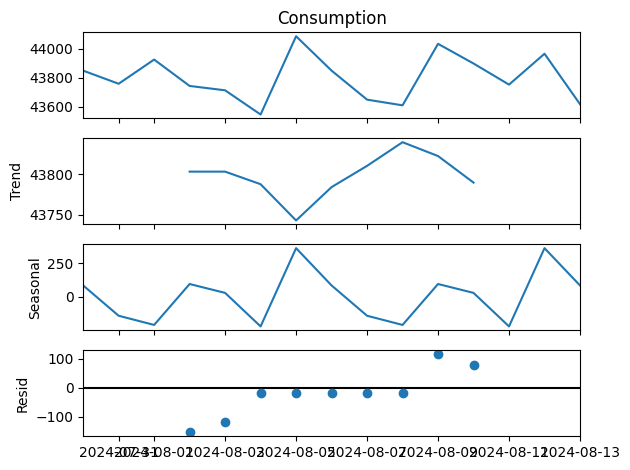

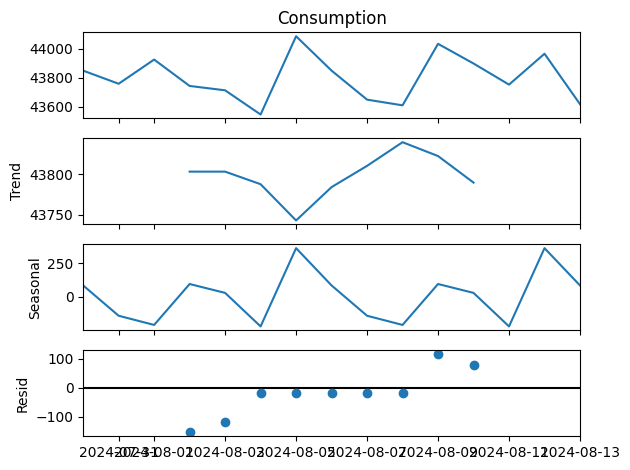

In [30]:
from statsmodels.tsa.seasonal import seasonal_decompose

# apply decomposition
result = seasonal_decompose(daily_consumption['Consumption'], model='additive', period=7)

# plot result
result.plot()

In [31]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Consumption'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -0.7665777149307474
p-value: 0.8287430521982315


In [32]:
# 4. Apply differencing on Consumption column
df['consumption_diff'] = df['Consumption'].diff()

In [33]:
# 5. Drop NaN values (created due to diff)
df = df.dropna()

In [34]:
# 6. Run ADF test on differenced data
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['consumption_diff'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -11.46083395460816
p-value: 5.560001847385827e-21


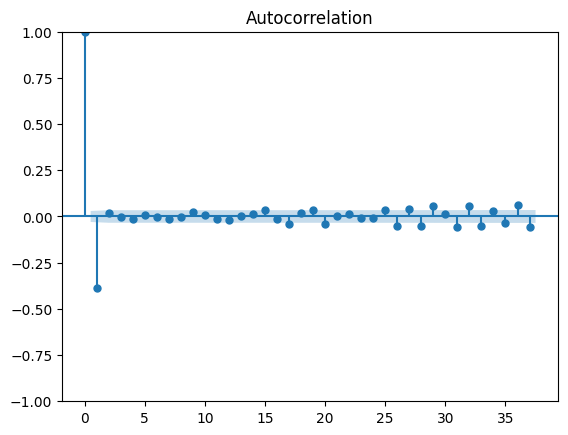

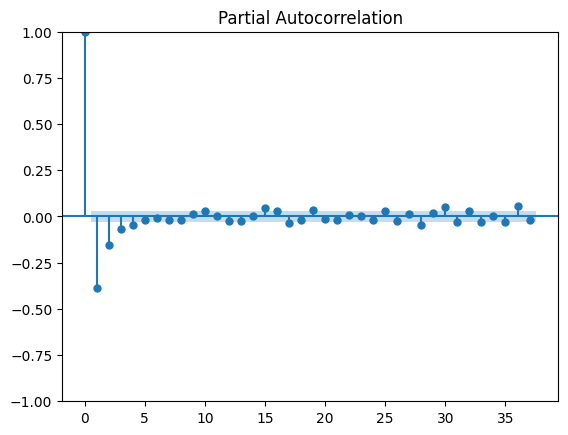

In [35]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Use stationary data
plot_acf(df['consumption_diff'])
plot_pacf(df['consumption_diff'])

plt.show()

In [36]:
# Step 1: Train-Test Split (Time-based)

train_size = int(len(df) * 0.8)

train = df[:train_size]
test = df[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 3455
Test size: 864


In [37]:
# Step 2: Naive Forecast (on test data)

test['naive_forecast'] = test['Consumption'].shift(1)

# Fix first value using last train value
test['naive_forecast'].iloc[0] = train['Consumption'].iloc[-1]

/tmp/ipykernel_14283/1043556659.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['naive_forecast'] = test['Consumption'].shift(1)
/tmp/ipykernel_14283/1043556659.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform 

In [38]:
# Step 3: Moving Average Forecast (window = 3)

window = 3

history = list(train['Consumption'])
ma_predictions = []

for t in range(len(test)):
    yhat = sum(history[-window:]) / window
    ma_predictions.append(yhat)
    history.append(test['Consumption'].iloc[t])

test['ma_forecast'] = ma_predictions

/tmp/ipykernel_14283/1383012899.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['ma_forecast'] = ma_predictions


In [40]:
# Step 4: Evaluate Models

from sklearn.metrics import mean_absolute_error

test_clean = test.dropna()

mean_value = test_clean['Consumption'].mean()

mae_percent_naive = (mae_naive / mean_value) * 100
mae_percent_ma = (mae_ma / mean_value) * 100

print("Naive MAE %:", mae_percent_naive)
print("Moving Avg MAE %:", mae_percent_ma)

Naive MAE %: 4.911030397470125
Moving Avg MAE %: 4.158331137260294


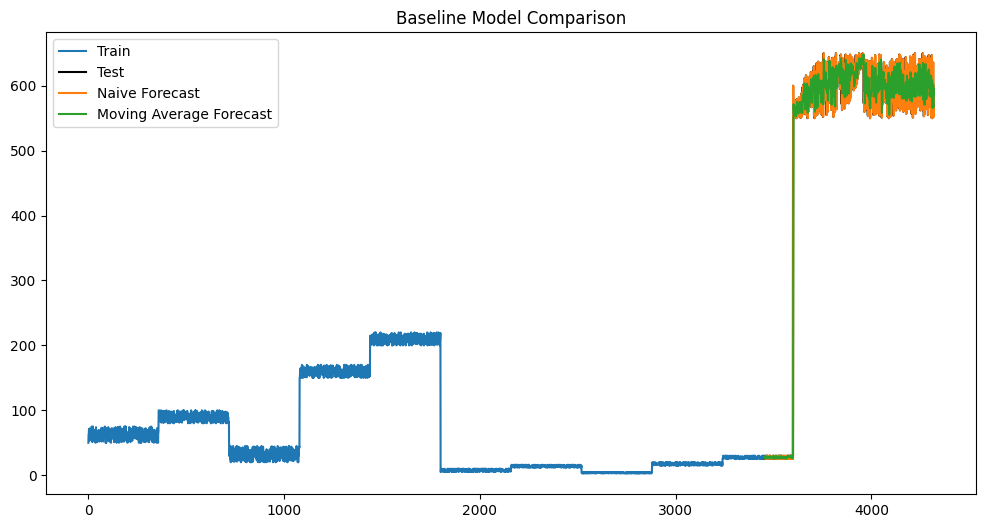

In [41]:
# Step 5: Plot Results

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(train['Consumption'], label='Train')
plt.plot(test['Consumption'], label='Test', color='black')

plt.plot(test['naive_forecast'], label='Naive Forecast')
plt.plot(test['ma_forecast'], label='Moving Average Forecast')

plt.legend()
plt.title("Baseline Model Comparison")
plt.show()

In [43]:
# Mean of actual values (test data)
mean_value = test_clean['Consumption'].mean()

# MAE %
mae_percent_naive = (mae_naive / mean_value) * 100
mae_percent_ma = (mae_ma / mean_value) * 100

# RMSE %
rmse_percent_naive = (rmse_naive / mean_value) * 100
rmse_percent_ma = (rmse_ma / mean_value) * 100

print("Naive MAE %:", mae_percent_naive)
print("Naive RMSE %:", rmse_percent_naive)

print("Moving Avg MAE %:", mae_percent_ma)
print("Moving Avg RMSE %:", rmse_percent_ma)

Naive MAE %: 4.911030397470125
Naive RMSE %: 7.485534593719377
Moving Avg MAE %: 4.158331137260294
Moving Avg RMSE %: 6.976894560840852
